In [2]:
import pandas as pd
import helpers as h
import config as c
import numpy as np

In [3]:
print("test")

test


# Spot Price Data 2025

In [4]:
INPUT_SPOT_CSV   = "../data_in/data_spot/Elspotprices.csv"
INPUT_DAP_CSV    = "../data_in/data_spot/DayAheadPrices.csv"
OUTPUT_CSV       = "../data_out/spot_prices_2025_complete.csv"

# historical hourly 2025 upto october
df_spot = h._load_hourly(
    INPUT_SPOT_CSV,
    ts_col_candidates=["TimeUTC", "HourUTC"],
    price_col="SpotPriceDKK",
    price_alias="spot_price_dkk_per_mwh",
)

# historical 15 min day ahead from october
df_dap = h._load_hourly(
    INPUT_DAP_CSV,
    ts_col_candidates=["TimeUTC", "TimeDK"],
    price_col="DayAheadPriceDKK",
    price_alias="spot_price_dkk_per_mwh",
)

df_spot["source"] = "spot"
df_dap["source"] = "dayahead"

df = (
    pd.concat([df_spot, df_dap], ignore_index=True)
    .pipe(lambda d: d[d["price_area"].str.strip() == c.PRICE_AREA])
    .assign(_source_priority=lambda d: d["source"].map({"spot": 0, "dayahead": 1}).fillna(99))
    .sort_values(["timestamp_utc", "_source_priority"])
    .drop_duplicates(subset=["timestamp_utc"], keep="first")
    .drop(columns=["source", "_source_priority"])
    .reset_index(drop=True)
)

expected_hours_2025 = pd.date_range("2025-01-01 00:00:00", "2025-12-31 23:00:00", freq="h")
present_hours = pd.DatetimeIndex(df["timestamp_utc"].dropna().drop_duplicates())
missing_hours = expected_hours_2025.difference(present_hours)
if len(missing_hours) > 0:
    print(f"Warning: missing {len(missing_hours)} hourly price points for 2025.")
    print(f"First missing hour: {missing_hours[0]}")
    print(f"Last missing hour: {missing_hours[-1]}")

# Force full 2025 hourly coverage and fill missing terminal gaps from nearest known price
df = (
    pd.DataFrame({"timestamp_utc": expected_hours_2025})
    .merge(df, on="timestamp_utc", how="left")
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)
df["price_area"] = df["price_area"].fillna(c.PRICE_AREA)
df["spot_price_dkk_per_mwh"] = pd.to_numeric(
    df["spot_price_dkk_per_mwh"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
).ffill().bfill()

# ============================================================
# PRICE CALCULATIONS
# ============================================================

df["spot_exkl_vat_ore_kwh"] = df["spot_price_dkk_per_mwh"] / 10  # DKK/MWh → øre/kWh

df["dso_tariff_exkl_vat_ore_kwh"] = df["timestamp_utc"].apply(
    lambda ts: h.get_dso_tariff(ts, c.DSO_TARIFFS)
)

# Buy price (consumer pays)
df["buy_price_exkl_vat_ore_kwh"] = (
    df["spot_exkl_vat_ore_kwh"]
    + df["dso_tariff_exkl_vat_ore_kwh"]
    + c.STATE_FEES["transmission"]
    + c.STATE_FEES["system_fee"]
    + c.STATE_FEES["elafgift"]
)
df["buy_price_inkl_vat_ore_kwh"] = df["buy_price_exkl_vat_ore_kwh"] * c.VAT_MULTIPLIER

# Sell price (prosumer receives)
df["sell_price_exkl_vat_ore_kwh"] = df["spot_exkl_vat_ore_kwh"] - c.FEEDIN_TARIFF_EXKL
df["sell_price_inkl_vat_ore_kwh"] = df["spot_exkl_vat_ore_kwh"] - c.FEEDIN_TARIFF_INKL

# ============================================================
# EXPORT
# ============================================================

df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Exported {len(df)} rows → {OUTPUT_CSV}")
df.head()

First missing hour: 2025-12-31 23:00:00
Last missing hour: 2025-12-31 23:00:00
Exported 8760 rows → data_out/spot_prices_2025_complete.csv


,timestamp_utc,price_area,spot_price_dkk_per_mwh,spot_exkl_vat_ore_kwh,dso_tariff_exkl_vat_ore_kwh,buy_price_exkl_vat_ore_kwh,buy_price_inkl_vat_ore_kwh,sell_price_exkl_vat_ore_kwh,sell_price_inkl_vat_ore_kwh
0,2025-01-01 00:00:00,DK2,14.39,1.439,9.76,23.199,28.99875,0.967,0.849
1,2025-01-01 01:00:00,DK2,14.39,1.439,9.76,23.199,28.99875,0.967,0.849
2,2025-01-01 02:00:00,DK2,10.66,1.066,9.76,22.826,28.53250,0.594,0.476
3,2025-01-01 03:00:00,DK2,7.76,0.776,9.76,22.536,28.17000,0.304,0.186
4,2025-01-01 04:00:00,DK2,17.00,1.700,9.76,23.460,29.32500,1.228,1.110


# Weather Data 2025 Actual + Forecasts

In [5]:
# ============================================================
# FETCH ACTUALS + HISTORICAL FORECASTS
# ============================================================

actual_params = {
    "latitude": c.LATITUDE,
    "longitude": c.LONGITUDE,
    "start_date": c.START_DATE,
    "end_date": c.END_DATE,
    "hourly": ",".join(c.WEATHER_VARS),
    "timezone": "UTC",
}

forecast_params = {
    "latitude": c.LATITUDE,
    "longitude": c.LONGITUDE,
    "start_date": c.START_DATE,
    "end_date": c.END_DATE,
    "hourly": ",".join(c.WEATHER_VARS),
    "timezone": "UTC",
    "models": "best_match",
}

actual_payload = h._fetch_open_meteo(c.ACTUAL_API_URL, actual_params, "actual historical weather")
forecast_payload = h._fetch_open_meteo(c.FORECAST_API_URL, forecast_params, "historical forecasts")

actual_col_map = {
    "temperature_2m": "mean_temp",
    "shortwave_radiation": "mean_radiation",
    "wind_speed_10m": "mean_wind_speed",
    "relative_humidity_2m": "mean_relative_hum",
    "precipitation": "acc_precip",
}

forecast_col_map = {
    "temperature_2m": "temp_forecast",
    "shortwave_radiation": "solar_forecast",
    "wind_speed_10m": "wind_forecast",
    "relative_humidity_2m": "relative_hum_forecast",
    "precipitation": "precip_forecast",
}

df_actual = h._build_weather_df(actual_payload["hourly"], actual_col_map)
df_forecast = h._build_weather_df(forecast_payload["hourly"], forecast_col_map)

# Keep the original notebook-compatible historical weather file for downstream merges
df_actual = df_actual.sort_values("timestamp").reset_index(drop=True)
df_actual.to_csv(c.OUTPUT_ACTUAL_CSV, index=False)

# Create a comparison file with both actuals and archived forecasts
df_weather_comparison = df_actual.merge(df_forecast, on="timestamp", how="inner")
df_weather_comparison["unique_id"] = "dk2_community_01"
df_weather_comparison.to_csv(c.OUTPUT_COMPARISON_CSV, index=False)

print(f"Saved actual historical weather: {len(df_actual)} rows → {c.OUTPUT_ACTUAL_CSV}")
print(f"Saved weather actuals vs forecasts: {len(df_weather_comparison)} rows → {c.OUTPUT_COMPARISON_CSV}")
print(df_weather_comparison.head())

Fetching actual historical weather …
Fetching historical forecasts …
Saved actual historical weather: 8784 rows → data_out/weather_data_2025_historical.csv
Saved weather actuals vs forecasts: 8784 rows → data_out/weather_actuals_vs_forecasts_2025.csv
            timestamp  mean_temp  mean_radiation  mean_wind_speed  \
0 2025-01-01 00:00:00        5.6             0.0             40.1   
1 2025-01-01 01:00:00        5.8             0.0             40.1   
2 2025-01-01 02:00:00        5.8             0.0             40.3   
3 2025-01-01 03:00:00        6.2             0.0             40.9   
4 2025-01-01 04:00:00        6.8             0.0             43.8   

   mean_relative_hum  acc_precip  temp_forecast  solar_forecast  \
0                 88         0.5            5.6             0.0   
1                 90         0.5            5.9             0.0   
2                 94         1.0            6.2             0.0   
3                 94         1.1            6.6             0.0   

# EC Data Conusmption and PV production

In [6]:
# import pandas as pd
# import numpy as np
# from sklearn.impute import KNNImputer

# INPUT_CONSUMPTION_CSV_B = "data_in/b_data.csv"
# INPUT_CONSUMPTION_CSV_S = "data_in/s_data.csv"
# OUTPUT_INTERP_CSV_B = "data_out/b_data_knn_sc_interpolated_2025.csv"
# OUTPUT_INTERP_CSV_S = "data_out/s_data_knn_sc_interpolated_2025.csv"

# expected_hours_2025 = pd.date_range(
#     "2025-01-01 00:00:00",
#     "2025-12-31 23:00:00",
#     freq="h",
# )
# expected_count = len(expected_hours_2025)


# def _parse_consumption(series):
#     return pd.to_numeric(
#         series.astype(str).str.replace(",", ".", regex=False), errors="coerce"
#     )


# def compare_observations_per_serial(
#     df,
#     dataset_name,
#     serial_col="Serial",
#     time_col="reading_time",
#     value_col="Consumption",
# ):
#     print(f"\n=== {dataset_name} ===")
#     print(f"Expected hours per serial in 2025: {expected_count}")
#     work = df.copy()
#     work[time_col] = pd.to_datetime(
#         work[time_col], errors="coerce", utc=True
#     ).dt.tz_convert(None)
#     work[value_col] = _parse_consumption(work[value_col])
#     work = work.dropna(subset=[serial_col, time_col])
#     summary = (
#         work.assign(hour=work[time_col].dt.floor("h"))
#         .groupby(serial_col, dropna=False)
#         .agg(
#             observed_unique_hours=("hour", "nunique"),
#             non_null_consumption=(value_col, lambda s: s.notna().sum()),
#         )
#         .reset_index()
#         .sort_values(serial_col)
#     )
#     summary["diff_vs_expected_hours"] = (
#         summary["observed_unique_hours"] - expected_count
#     )
#     print(summary.to_string(index=False))


# def interpolate_to_full_hourly_2025_method6(
#     df,
#     serial_col="Serial",
#     time_col="reading_time",
#     value_col="Consumption",
#     knn_neighbors=5,
#     outlier_cap_kwh=50,
# ):
#     """
#     Method 6: KNN imputation on hourly deltas, then rescale each meter so
#     its total matches the odometer truth (cummax - cummin per meter).

#     Steps:
#       1. Parse timestamps and values; compute hourly deltas per meter.
#       2. Blank spikes caused by data gaps (time_gap > 1 h) and hard outliers.
#       3. Build a wide matrix [hours x meters] and run KNN imputation.
#       4. Rescale each meter column so sum(imputed) == odometer truth.
#       5. Return a long dataframe with columns [Serial, reading_time, Consumption]
#          where Consumption is the *hourly delta* (kWh) on the expected 2025 grid.
#     """
#     work = df.copy()
#     work[time_col] = (
#         pd.to_datetime(work[time_col], errors="coerce", utc=True)
#         .dt.tz_convert(None)
#         .dt.floor("h")
#     )
#     work[value_col] = _parse_consumption(work[value_col])
#     work = work.dropna(subset=[serial_col, time_col, value_col])
#     work = work.sort_values([serial_col, time_col])

#     # ── 1. Hourly delta + spike blanking ──────────────────────────────────────
#     work["time_gap"] = work.groupby(serial_col)[time_col].diff()
#     work["hourly_delta"] = (
#         work.groupby(serial_col)[value_col].diff().clip(lower=0)
#     )
#     # Reconnection spikes: gap > 1 h means the delta spans multiple hours
#     work.loc[work["time_gap"] > pd.Timedelta(hours=1), "hourly_delta"] = np.nan
#     # Hard outlier cap
#     work.loc[work["hourly_delta"] > outlier_cap_kwh, "hourly_delta"] = np.nan

#     # ── 2. Odometer truth per meter (cumulative max - min on raw readings) ────
#     odometer = (
#         work.groupby(serial_col)[value_col]
#         .agg(lambda s: s.max() - s.min())
#         .rename("odometer_kwh")
#     )

#     # ── 3. Wide matrix on expected 2025 grid ──────────────────────────────────
#     wide = (
#         work.groupby([time_col, serial_col])["hourly_delta"]
#         .mean()
#         .unstack(serial_col)      # columns = serials, index = timestamps
#         .reindex(expected_hours_2025)
#     )

#     # ── 4. KNN imputation ─────────────────────────────────────────────────────
#     imputer = KNNImputer(n_neighbors=knn_neighbors, weights="distance")
#     imputed_array = imputer.fit_transform(wide)
#     df_imputed = pd.DataFrame(
#         imputed_array, index=expected_hours_2025, columns=wide.columns
#     )
#     # Clip negatives that can appear after KNN
#     df_imputed = df_imputed.clip(lower=0)

#     # ── 5. Rescale each meter to match odometer truth ─────────────────────────
#     for serial in df_imputed.columns:
#         knn_total = df_imputed[serial].sum()
#         actual_total = odometer.get(serial, 0)
#         if knn_total > 0 and actual_total > 0:
#             df_imputed[serial] *= actual_total / knn_total

#     # ── 6. Melt back to long format ───────────────────────────────────────────
#     df_long = (
#         df_imputed
#         .reset_index()
#         .rename(columns={"index": time_col})
#         .melt(id_vars=time_col, var_name=serial_col, value_name=value_col)
#         [[serial_col, time_col, value_col]]
#         .sort_values([serial_col, time_col])
#         .reset_index(drop=True)
#     )
#     return df_long


# # ── Load ──────────────────────────────────────────────────────────────────────
# df_b = pd.read_csv(INPUT_CONSUMPTION_CSV_B)
# df_s = pd.read_csv(INPUT_CONSUMPTION_CSV_S)

# # ── Before interpolation ──────────────────────────────────────────────────────
# print("\n##### BEFORE INTERPOLATION #####")
# compare_observations_per_serial(df_b, "b_data.csv")
# compare_observations_per_serial(df_s, "s_data.csv")

# # ── Interpolate (Method 6) ────────────────────────────────────────────────────
# df_b_interp = interpolate_to_full_hourly_2025_method6(df_b)
# df_s_interp = interpolate_to_full_hourly_2025_method6(df_s)

# # ── Save ──────────────────────────────────────────────────────────────────────
# df_b_interp.to_csv(OUTPUT_INTERP_CSV_B, index=False)
# df_s_interp.to_csv(OUTPUT_INTERP_CSV_S, index=False)
# print(f"\nSaved interpolated B data: {len(df_b_interp)} rows -> {OUTPUT_INTERP_CSV_B}")
# print(f"Saved interpolated S data: {len(df_s_interp)} rows -> {OUTPUT_INTERP_CSV_S}")

# # ── After interpolation ───────────────────────────────────────────────────────
# print("\n##### AFTER INTERPOLATION #####")
# compare_observations_per_serial(df_b_interp, "b_data.csv (interpolated)")
# compare_observations_per_serial(df_s_interp, "s_data.csv (interpolated)")

In [7]:
# import pandas as pd
# import matplotlib.pyplot as plt

# RAW_B_CSV = "data_in/b_data.csv"
# RAW_S_CSV = "data_in/s_data.csv"
# INTERP_B_CSV = "data_out/b_data_knn_sc_interpolated_2025.csv"
# INTERP_S_CSV = "data_out/s_data_knn_sc_interpolated_2025.csv"


# def _to_hourly_from_raw(df_raw, serial_col="Serial", time_col="reading_time", value_col="Consumption"):
#     df = df_raw.copy()
#     df[time_col] = (
#         pd.to_datetime(df[time_col], errors="coerce", utc=True)
#         .dt.tz_convert(None)
#         .dt.floor("h")
#     )
#     df[value_col] = pd.to_numeric(
#         df[value_col].astype(str).str.replace(",", ".", regex=False),
#         errors="coerce",
#     )
#     df = df.dropna(subset=[serial_col, time_col, value_col])
#     df = df.sort_values([serial_col, time_col])

#     # Convert cumulative meter readings to hourly deltas
#     hourly = (
#         df.groupby([serial_col, time_col], as_index=False)[value_col].mean()
#         .sort_values([serial_col, time_col])
#     )
#     hourly["hourly_kwh"] = hourly.groupby(serial_col)[value_col].diff().clip(lower=0)
#     return hourly[[serial_col, time_col, "hourly_kwh"]]


# def _prepare_interpolated(df_interp, serial_col="Serial", time_col="reading_time", value_col="Consumption"):
#     df = df_interp.copy()
#     df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True).dt.tz_convert(None)
#     df[value_col] = pd.to_numeric(
#         df[value_col].astype(str).str.replace(",", ".", regex=False),
#         errors="coerce",
#     )
#     df = df.dropna(subset=[serial_col, time_col, value_col])
#     df = df.rename(columns={value_col: "hourly_kwh_interp"})
#     return df[[serial_col, time_col, "hourly_kwh_interp"]]


# def plot_original_vs_interpolated(raw_csv, interp_csv, dataset_label, n_meters=3):
#     raw = pd.read_csv(raw_csv)
#     interp = pd.read_csv(interp_csv)

#     raw_hourly = _to_hourly_from_raw(raw)
#     interp_hourly = _prepare_interpolated(interp)

#     common_serials = sorted(
#         set(raw_hourly["Serial"].dropna().unique()) & set(interp_hourly["Serial"].dropna().unique())
#     )

#     if not common_serials:
#         print(f"No common serials found for {dataset_label}.")
#         return

#     selected_serials = common_serials[:n_meters]
#     print(f"{dataset_label}: plotting serials {selected_serials}")

#     fig, axes = plt.subplots(len(selected_serials), 1, figsize=(14, 4 * len(selected_serials)), sharex=True)
#     if len(selected_serials) == 1:
#         axes = [axes]

#     for ax, serial in zip(axes, selected_serials):
#         raw_s = raw_hourly[raw_hourly["Serial"] == serial]
#         int_s = interp_hourly[interp_hourly["Serial"] == serial]

#         merged = raw_s.merge(
#             int_s,
#             on=["Serial", "reading_time"],
#             how="outer",
#         ).sort_values("reading_time")

#         ax.plot(
#             merged["reading_time"],
#             merged["hourly_kwh"],
#             label="Original (hourly delta)",
#             linewidth=1.0,
#             alpha=0.8,
#         )
#         ax.plot(
#             merged["reading_time"],
#             merged["hourly_kwh_interp"],
#             label="Interpolated",
#             linewidth=1.0,
#             alpha=0.8,
#         )
#         ax.set_title(f"{dataset_label} | Serial {serial}")
#         ax.set_ylabel("kWh")
#         ax.grid(alpha=0.3)
#         ax.legend(loc="upper right")

#     axes[-1].set_xlabel("Time")
#     plt.tight_layout()
#     plt.show()


# plot_original_vs_interpolated(RAW_B_CSV, INTERP_B_CSV, "B dataset", n_meters=3)
# plot_original_vs_interpolated(RAW_S_CSV, INTERP_S_CSV, "S dataset", n_meters=3)

In [8]:
# based on this notebook make a function that input cumulative raw, get hourly cleaned. exactly like the previous cells do
# inputs: path to raw cumulative csv, path to output cleaned csv

def build_cleaned_cumulative(
    input_csv_path,
    output_csv_path,
    start_time="2025-01-01 00:00:00",
    end_time="2026-01-01 00:00:00",
):
    # 1) load + standardize columns
    df_raw = pd.read_csv(input_csv_path).drop(columns=["Unnamed: 0"], errors="ignore")
    df_raw = df_raw.loc[:, ~df_raw.columns.duplicated()].copy()

    rename_map = {}
    if "reading_time" in df_raw.columns and "timestamp" not in df_raw.columns:
        rename_map["reading_time"] = "timestamp"
    if "Consumption" in df_raw.columns and "consumption_cumulative_kwh" not in df_raw.columns:
        rename_map["Consumption"] = "consumption_cumulative_kwh"

    # normalize serial-style names to the expected 'Serial'
    if "Serial" not in df_raw.columns:
        for candidate in ["serial", "SERIAL", "serieal", "Serieal", "meter_id", "meterId"]:
            if candidate in df_raw.columns:
                rename_map[candidate] = "Serial"
                break

    if rename_map:
        df_raw = df_raw.rename(columns=rename_map)

    required_cols = {"Serial", "timestamp", "consumption_cumulative_kwh"}
    missing_cols = required_cols.difference(df_raw.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    # 2) timestamp cleanup + ordering
    df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], errors="coerce").dt.round("h")
    df_raw = df_raw.dropna(subset=["timestamp"]).copy()
    df_raw = df_raw.sort_values(["Serial", "timestamp"]).reset_index(drop=True)

    # 3) keep all Serial values (including negative PV meters)

    # 4) expected hourly grid
    expected_hours_df = pd.DataFrame({
        "timestamp": pd.date_range(
            start=pd.Timestamp(start_time),
            end=pd.Timestamp(end_time),
            freq="h",
            inclusive="left",
        )
    })

    serials_df = pd.DataFrame({"Serial": np.sort(df_raw["Serial"].unique())})
    expected_grid = serials_df.merge(expected_hours_df, how="cross")

    # 5) merge actual cumulative data on full grid
    actual_df = df_raw[["Serial", "timestamp", "consumption_cumulative_kwh"]].copy()
    actual_df["consumption_cumulative_kwh"] = pd.to_numeric(
        actual_df["consumption_cumulative_kwh"],
        errors="coerce",
    )
    actual_df = actual_df.drop_duplicates(subset=["Serial", "timestamp"], keep="last")

    df_clean = expected_grid.merge(
        actual_df,
        on=["Serial", "timestamp"],
        how="left",
    )
    df_clean = df_clean.sort_values(["Serial", "timestamp"]).reset_index(drop=True)

    # 6) interpolation on cumulative values (keep original + add interpolated col)
    before_na_mask = df_clean["consumption_cumulative_kwh"].isna()
    df_clean["consumption_cumulative_kwh_interpolated"] = (
        df_clean.groupby("Serial")["consumption_cumulative_kwh"]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )
    after_na_mask = df_clean["consumption_cumulative_kwh_interpolated"].isna()
    df_clean["corrected_consumption_value"] = (before_na_mask & ~after_na_mask).astype(int)

    # 7) transform to hourly delta (new columns, keep cumulative untouched)
    df_clean["hourly_consumption_kwh"] = (
        df_clean.groupby("Serial")["consumption_cumulative_kwh"].diff()
    )
    df_clean["hourly_consumption_kwh_interpolated"] = (
        df_clean.groupby("Serial")["consumption_cumulative_kwh_interpolated"].diff()
    )

    # 8) backfill first hourly value per serial
    first_row_mask = df_clean.groupby("Serial").cumcount() == 0
    hourly_cols = ["hourly_consumption_kwh", "hourly_consumption_kwh_interpolated"]
    bfill_hourly = df_clean.groupby("Serial")[hourly_cols].transform("bfill")
    df_clean.loc[first_row_mask, hourly_cols] = bfill_hourly.loc[first_row_mask, hourly_cols]

    # 9) final output columns: cumulative interpolated output (keep Serial for next cell)
    df_output = df_clean[[
        "Serial",
        "timestamp",
        "consumption_cumulative_kwh_interpolated",
        "corrected_consumption_value",
    ]].copy()
    df_output["time"] = df_output["timestamp"].dt.strftime("%H:%M:%S")
    df_output = df_output[[
        "Serial",
        "timestamp",
        "time",
        "consumption_cumulative_kwh_interpolated",
        "corrected_consumption_value",
    ]]

    # 10) save final output
    df_output.to_csv(output_csv_path, index=False)

    # 11) quick validation summary from full table
    rows_per_serial = df_clean.groupby("Serial").size().reset_index(name="row_count")
    expected_rows = len(expected_hours_df)
    rows_per_serial["is_expected"] = rows_per_serial["row_count"] == expected_rows

    print(f"Saved cleaned cumulative file to: {output_csv_path}")
    print(f"Expected rows per serial: {expected_rows}")
    print(f"Serials matching expected rows: {int(rows_per_serial['is_expected'].sum())}/{len(rows_per_serial)}")
    print(f"Corrected (filled) values: {int(df_clean['corrected_consumption_value'].sum())}")

    return df_output, rows_per_serial


INPUT_CONSUMPTION_CSV_B = "data_in/b_data.csv"
OUTPUT_INTERP_CSV_B = "data_out/b_data_cumulative_cleaned_2025.csv"
INPUT_CONSUMPTION_CSV_S = "data_in/s_data.csv"
OUTPUT_INTERP_CSV_S = "data_out/s_data_cumulative_cleaned_2025.csv"

df_b_output, df_b_rows_check = build_cleaned_cumulative(
    input_csv_path=INPUT_CONSUMPTION_CSV_B,
    output_csv_path=OUTPUT_INTERP_CSV_B,
)

df_s_output, df_s_rows_check = build_cleaned_cumulative(
    input_csv_path=INPUT_CONSUMPTION_CSV_S,
    output_csv_path=OUTPUT_INTERP_CSV_S,
)

print(df_b_output.head())
print(df_s_output.head())

Saved cleaned cumulative file to: data_out/b_data_cumulative_cleaned_2025.csv
Expected rows per serial: 8760
Serials matching expected rows: 57/57
Corrected (filled) values: 3299
Saved cleaned cumulative file to: data_out/s_data_cumulative_cleaned_2025.csv
Expected rows per serial: 8760
Serials matching expected rows: 63/63
Corrected (filled) values: 4123
   Serial           timestamp      time  \
0      -1 2025-01-01 00:00:00  00:00:00   
1      -1 2025-01-01 01:00:00  01:00:00   
2      -1 2025-01-01 02:00:00  02:00:00   
3      -1 2025-01-01 03:00:00  03:00:00   
4      -1 2025-01-01 04:00:00  04:00:00   

   consumption_cumulative_kwh_interpolated  corrected_consumption_value  
0                                 75846.69                            0  
1                                 75846.69                            0  
2                                 75846.69                            0  
3                                 75846.69                            0  
4            

In [9]:
# print a week and a day for meter 2 in August from exported cumulative corrected files
METER_ID = 2

exported_files = {
    "B": "../data_out/b_data_cumulative_cleaned_2025.csv",
    "S": "../data_out/s_data_cumulative_cleaned_2025.csv",
}

week_start = pd.Timestamp("2025-08-01 00:00:00")
week_end = pd.Timestamp("2025-08-08 00:00:00")
day_start = pd.Timestamp("2025-08-06 00:00:00")
day_end = pd.Timestamp("2025-08-07 00:00:00")

for label, path in exported_files.items():
    print("\n" + "=" * 90)
    print(f"{label} file -> {path}")
    print("=" * 90)

    df = pd.read_csv(path)
    if "Serial" not in df.columns:
        print("Missing 'Serial' column in file.")
        continue

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()
    meter_df = df[df["Serial"] == METER_ID].sort_values("timestamp")

    if meter_df.empty:
        print(f"No rows found for meter {METER_ID}.")
        continue

    week_df = meter_df[(meter_df["timestamp"] >= week_start) & (meter_df["timestamp"] < week_end)]
    day_df = meter_df[(meter_df["timestamp"] >= day_start) & (meter_df["timestamp"] < day_end)]

    print(f"\nWeek view ({week_start} to {week_end}, meter {METER_ID})")
    print(week_df.to_string(index=False))

    print(f"\nDay view ({day_start.date()}, meter {METER_ID})")
    print(day_df.to_string(index=False))


B file -> data_out/b_data_cumulative_cleaned_2025.csv

Week view (2025-08-01 00:00:00 to 2025-08-08 00:00:00, meter 2)
 Serial           timestamp     time  consumption_cumulative_kwh_interpolated  corrected_consumption_value
      2 2025-08-01 00:00:00 00:00:00                              1413.600000                            0
      2 2025-08-01 01:00:00 01:00:00                              1413.600000                            0
      2 2025-08-01 02:00:00 02:00:00                              1413.600000                            0
      2 2025-08-01 03:00:00 03:00:00                              1413.600000                            0
      2 2025-08-01 04:00:00 04:00:00                              1413.600000                            0
      2 2025-08-01 05:00:00 05:00:00                              1413.600000                            1
      2 2025-08-01 06:00:00 06:00:00                              1413.600000                            0
      2 2025-08-01 07:00

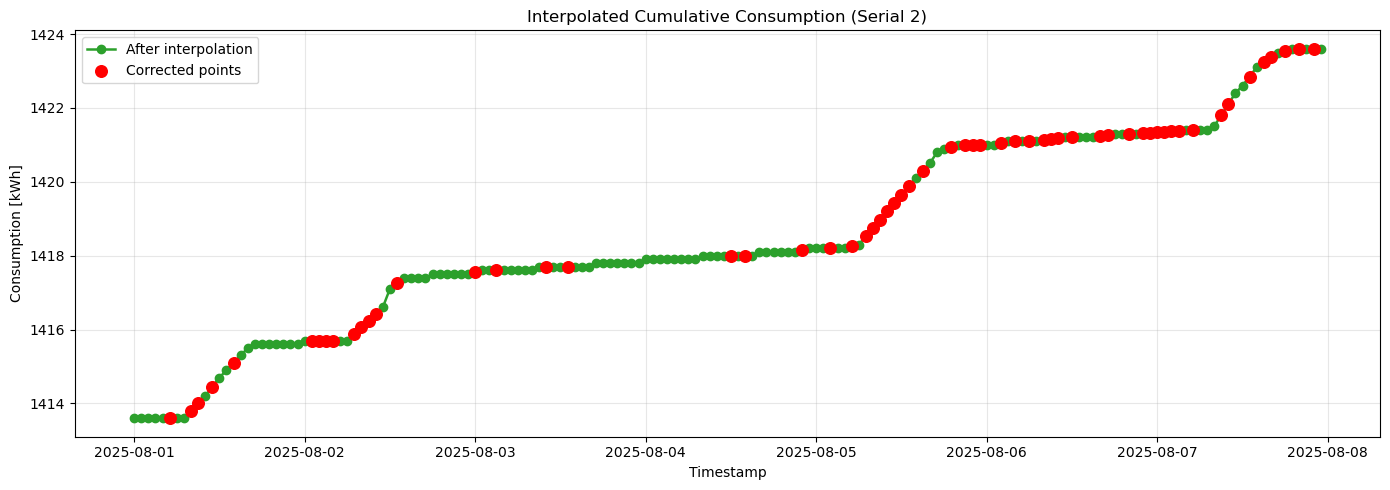

In [10]:
# add plot here
import matplotlib.pyplot as plt

PLOT_FILE = "../data_out/b_data_cumulative_cleaned_2025.csv"
SERIAL_TEST = 2
day_start = pd.Timestamp("2025-08-01 00:00:00")
day_end = pd.Timestamp("2025-08-08 00:00:00")  # exclusive upper bound

plot_df = pd.read_csv(PLOT_FILE)
plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"], errors="coerce")
plot_df = plot_df.dropna(subset=["timestamp"]).sort_values("timestamp")

example_day = plot_df[plot_df["Serial"] == SERIAL_TEST].copy()
example_day = example_day.loc[
    (example_day["timestamp"] >= day_start) & (example_day["timestamp"] < day_end)
]

if example_day.empty:
    print(f"No data for Serial {SERIAL_TEST} in {day_start} to {day_end}.")
else:
    plt.figure(figsize=(14, 5))

    plt.plot(
        example_day["timestamp"],
        example_day["consumption_cumulative_kwh_interpolated"],
        marker="o",
        linewidth=1.8,
        color="tab:green",
        label="After interpolation",
    )

    corrected_mask = example_day["corrected_consumption_value"] == 1
    if corrected_mask.any():
        plt.scatter(
            example_day.loc[corrected_mask, "timestamp"],
            example_day.loc[corrected_mask, "consumption_cumulative_kwh_interpolated"],
            color="red",
            s=70,
            zorder=3,
            label="Corrected points",
        )

    plt.title(f"Interpolated Cumulative Consumption (Serial {SERIAL_TEST})")
    plt.xlabel("Timestamp")
    plt.ylabel("Consumption [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================
# CONFIGURATION — change values here
# ============================================================


INPUT_CONSUMPTION_CSV_B = "../data_out/b_data_cumulative_cleaned_2025.csv"
INPUT_CONSUMPTION_CSV_S = "../data_out/s_data_cumulative_cleaned_2025.csv"
INPUT_PRICES_CSV        = "../data_out/spot_prices_2025_complete.csv"
INPUT_WEATHER_CSV       = "../data_out/weather_actuals_vs_forecasts_2025.csv"

OUTPUT_CSV              = "../data_out/combined_2025.csv"

PV_SERIAL_B             = -1   # Serial number used to identify PV production meter in b dataset
PV_SERIAL_S             = -2   # Serial number used to identify PV production meter in s dataset

PRICE_COLS_TO_KEEP      = [
    "timestamp_utc",
    "spot_exkl_vat_ore_kwh",
    "buy_price_inkl_vat_ore_kwh",
    "sell_price_inkl_vat_ore_kwh",
]


def _load_for_combine(path):
    df_raw = pd.read_csv(path).drop(columns=["Unnamed: 0"], errors="ignore")
    df_raw = df_raw.loc[:, ~df_raw.columns.duplicated()].copy()

    rename_map = {}
    if "reading_time" in df_raw.columns and "timestamp" not in df_raw.columns:
        rename_map["reading_time"] = "timestamp"
    if "Consumption" in df_raw.columns and "consumption_cumulative_kwh" not in df_raw.columns:
        rename_map["Consumption"] = "consumption_cumulative_kwh"
    if "Serial" not in df_raw.columns:
        for candidate in ["serial", "SERIAL", "serieal", "Serieal", "meter_id", "meterId"]:
            if candidate in df_raw.columns:
                rename_map[candidate] = "Serial"
                break
    if rename_map:
        df_raw = df_raw.rename(columns=rename_map)

    if "Serial" not in df_raw.columns:
        raise ValueError(f"Input file '{path}' is missing 'Serial'.")
    if "timestamp" not in df_raw.columns:
        raise ValueError(f"Input file '{path}' is missing 'timestamp' (or 'reading_time').")

    timestamp_series = df_raw["timestamp"]
    if isinstance(timestamp_series, pd.DataFrame):
        timestamp_series = timestamp_series.iloc[:, 0]
    df_raw["timestamp"] = pd.to_datetime(timestamp_series, errors="coerce").dt.round("h")
    df_raw = df_raw.dropna(subset=["Serial", "timestamp"]).copy()
    df_raw = df_raw.sort_values(["Serial", "timestamp"]).reset_index(drop=True)

    if "consumption_cumulative_kwh_interpolated" in df_raw.columns:
        df_raw["consumption_cumulative_kwh_interpolated"] = pd.to_numeric(
            df_raw["consumption_cumulative_kwh_interpolated"], errors="coerce"
        )
        df_raw["hourly_consumption_kwh"] = (
            df_raw.groupby("Serial")["consumption_cumulative_kwh_interpolated"].diff()
        )
    elif "consumption_cumulative_kwh" in df_raw.columns:
        df_raw["consumption_cumulative_kwh"] = pd.to_numeric(
            df_raw["consumption_cumulative_kwh"], errors="coerce"
        )
        df_raw["hourly_consumption_kwh"] = (
            df_raw.groupby("Serial")["consumption_cumulative_kwh"].diff()
        )
    elif "hourly_consumption_kwh" in df_raw.columns:
        df_raw["hourly_consumption_kwh"] = pd.to_numeric(df_raw["hourly_consumption_kwh"], errors="coerce")
    else:
        raise ValueError(
            f"Unsupported schema in '{path}'. Expected cumulative or hourly consumption column."
        )

    df_raw.loc[df_raw.groupby("Serial").cumcount() == 0, "hourly_consumption_kwh"] = None
    return df_raw

# ============================================================
# LOAD & CLEAN CONSUMPTION (B + S)
# ============================================================

df_b_raw = _load_for_combine(INPUT_CONSUMPTION_CSV_B)
df_s_raw = _load_for_combine(INPUT_CONSUMPTION_CSV_S)

df_b_hourly = h._build_hourly_consumption(df_b_raw, "b", PV_SERIAL_B)
df_s_hourly = h._build_hourly_consumption(df_s_raw, "s", PV_SERIAL_S)

df_consumption = (
    pd.concat([df_b_hourly, df_s_hourly], ignore_index=True)
    .sort_values(["timestamp", "ec_id"])
    .reset_index(drop=True)
)

df_consumption["consumption"] = pd.to_numeric(
    df_consumption["consumption"], errors="coerce"
 )

# ============================================================
# BUILD PV SERIES FROM B + S DATA
# ============================================================

df_b_pv_hourly = h._build_hourly_production(df_b_raw, "b", PV_SERIAL_B)
df_s_pv_hourly = h._build_hourly_production(df_s_raw, "s", PV_SERIAL_S)

df_pv_hourly = pd.concat([df_b_pv_hourly, df_s_pv_hourly], ignore_index=True)

# Keep all timestamp+ec rows that exist in consumption and attach matching PV
all_rows = df_consumption[["timestamp", "ec_id"]].drop_duplicates()
df_pv_hourly = all_rows.merge(df_pv_hourly, on=["timestamp", "ec_id"], how="left")

# Note: NaN handling for PV production is done later in 3_DATA_DESCRIPTION.ipynb
pv_nan_count = df_pv_hourly["pv_production_kwh"].isna().sum()

df_combined = df_consumption.merge(
    df_pv_hourly, on=["timestamp", "ec_id"], how="left"
)

df_combined.head(50)

,timestamp,ec_id,consumption,pv_production_kwh
0,2025-01-01 00:00:00,b,0.00,0.00
1,2025-01-01 00:00:00,s,0.00,0.00
2,2025-01-01 01:00:00,b,5.50,0.00
3,2025-01-01 01:00:00,s,7.60,0.00
4,2025-01-01 02:00:00,b,7.90,0.00
5,2025-01-01 02:00:00,s,9.70,0.00
6,2025-01-01 03:00:00,b,6.65,0.00
7,2025-01-01 03:00:00,s,8.30,0.00
8,2025-01-01 04:00:00,b,6.05,0.00
9,2025-01-01 04:00:00,s,8.30,0.00


# Combine into final DF

In [12]:
# ============================================================
# LOAD PRICES & WEATHER
# ============================================================

df_prices = pd.read_csv(INPUT_PRICES_CSV, usecols=PRICE_COLS_TO_KEEP)
df_prices["timestamp_utc"] = pd.to_datetime(df_prices["timestamp_utc"])

df_weather = pd.read_csv(INPUT_WEATHER_CSV)
df_weather["timestamp"] = pd.to_datetime(df_weather["timestamp"]).dt.tz_localize(None)

# ============================================================
# MERGE INTO COMBINED DATAFRAME
# ============================================================

df_combined["timestamp"] = pd.to_datetime(df_combined["timestamp"]).dt.tz_localize(None)
df_prices["timestamp_utc"] = df_prices["timestamp_utc"].dt.tz_localize(None)

df_combined = (
    df_combined
    .merge(df_prices, left_on="timestamp", right_on="timestamp_utc", how="left")
    .drop(columns=["timestamp_utc"])
    .merge(df_weather, on="timestamp", how="left")
    .sort_values(["timestamp", "ec_id"])
    .reset_index(drop=True)
)

# ============================================================
# EXPORT
# ============================================================

df_combined.to_csv(OUTPUT_CSV, index=False)
print(f"Exported {len(df_combined)} rows → {OUTPUT_CSV}")
print(f"PV NaN values before handling: {pv_nan_count}")
print(df_combined[["timestamp", "ec_id", "consumption", "pv_production_kwh"]].head())
df_combined

Exported 17520 rows → data_out/combined_2025.csv
PV NaN values before handling: 0
            timestamp ec_id  consumption  pv_production_kwh
0 2025-01-01 00:00:00     b          0.0                0.0
1 2025-01-01 00:00:00     s          0.0                0.0
2 2025-01-01 01:00:00     b          5.5                0.0
3 2025-01-01 01:00:00     s          7.6                0.0
4 2025-01-01 02:00:00     b          7.9                0.0


,timestamp,ec_id,consumption,pv_production_kwh,spot_exkl_vat_ore_kwh,buy_price_inkl_vat_ore_kwh,sell_price_inkl_vat_ore_kwh,mean_temp,mean_radiation,mean_wind_speed,mean_relative_hum,acc_precip,temp_forecast,solar_forecast,wind_forecast,relative_hum_forecast,precip_forecast,unique_id
0,2025-01-01 00:00:00,b,0.0,0.0,1.439000,28.998750,0.849000,5.6,0.0,40.1,88,0.5,5.6,0.0,37.4,91,0.6,dk2_community_01
1,2025-01-01 00:00:00,s,0.0,0.0,1.439000,28.998750,0.849000,5.6,0.0,40.1,88,0.5,5.6,0.0,37.4,91,0.6,dk2_community_01
2,2025-01-01 01:00:00,b,5.5,0.0,1.439000,28.998750,0.849000,5.8,0.0,40.1,90,0.5,5.9,0.0,36.4,90,1.0,dk2_community_01
3,2025-01-01 01:00:00,s,7.6,0.0,1.439000,28.998750,0.849000,5.8,0.0,40.1,90,0.5,5.9,0.0,36.4,90,1.0,dk2_community_01
4,2025-01-01 02:00:00,b,7.9,0.0,1.066000,28.532500,0.476000,5.8,0.0,40.3,94,1.0,6.2,0.0,36.0,90,0.9,dk2_community_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,2025-12-31 21:00:00,s,22.3,0.0,54.534173,119.780216,53.944173,1.8,0.0,14.9,93,0.0,1.8,0.0,9.4,98,0.0,dk2_community_01
17516,2025-12-31 22:00:00,b,13.8,0.0,45.418380,108.385475,44.828380,1.6,0.0,14.4,95,0.0,2.1,0.0,12.6,99,0.0,dk2_community_01
17517,2025-12-31 22:00:00,s,14.3,0.0,45.418380,108.385475,44.828380,1.6,0.0,14.4,95,0.0,2.1,0.0,12.6,99,0.0,dk2_community_01
17518,2025-12-31 23:00:00,b,12.2,0.0,45.418380,108.385475,44.828380,2.1,0.0,16.6,93,0.1,2.4,0.0,14.0,98,0.0,dk2_community_01
